# Exercise 11

Read the RockMine.csv from the dataset section.  There is no column header.

a. Add a column header by giving name to columns as C1, C2, .....\
b. Sort its columns(except last label column) in increasing order of 'No.of distinct values'.\
c. Remove the last 10 columns from the database.\
d. Normalize other columns by subtracting each value from Mean value and dividing by Mean standard deviation.\
e. Run Any classification algorithm on new normalized dataset and report the accuracy.\
f. Scale all the features and normalize it. Discretize it to 5 levels

Gradually remove the features till you get the accuracy in the range.

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../../datasets/RockMine.csv.csv", header=None)
n_cols = df.shape[1]

df.columns = [f"C{i}" for i in range(1, n_cols + 1)]
df.head()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C52,C53,C54,C55,C56,C57,C58,C59,C60,C61
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [3]:
col_vs_size = {}
for col in df.columns[:-1]:
    num_uni = df[col].value_counts().shape[0]
    col_vs_size[col] = num_uni
print(col_vs_size)

{'C1': 177, 'C2': 182, 'C3': 190, 'C4': 181, 'C5': 193, 'C6': 196, 'C7': 195, 'C8': 201, 'C9': 205, 'C10': 207, 'C11': 203, 'C12': 206, 'C13': 198, 'C14': 202, 'C15': 203, 'C16': 203, 'C17': 202, 'C18': 204, 'C19': 206, 'C20': 203, 'C21': 200, 'C22': 203, 'C23': 199, 'C24': 201, 'C25': 198, 'C26': 194, 'C27': 190, 'C28': 194, 'C29': 197, 'C30': 202, 'C31': 207, 'C32': 205, 'C33': 205, 'C34': 206, 'C35': 205, 'C36': 205, 'C37': 206, 'C38': 206, 'C39': 204, 'C40': 206, 'C41': 204, 'C42': 208, 'C43': 205, 'C44': 196, 'C45': 205, 'C46': 199, 'C47': 202, 'C48': 204, 'C49': 193, 'C50': 154, 'C51': 160, 'C52': 144, 'C53': 134, 'C54': 134, 'C55': 129, 'C56': 122, 'C57': 121, 'C58': 124, 'C59': 119, 'C60': 109}


In [4]:
new_order = sorted(col_vs_size, key=col_vs_size.get)
labels = df[df.columns[-1]]
print(new_order)
sorted_df = df[new_order]
sorted_df.head()

['C60', 'C59', 'C57', 'C56', 'C58', 'C55', 'C53', 'C54', 'C52', 'C50', 'C51', 'C1', 'C4', 'C2', 'C3', 'C27', 'C5', 'C49', 'C26', 'C28', 'C7', 'C6', 'C44', 'C29', 'C13', 'C25', 'C23', 'C46', 'C21', 'C8', 'C24', 'C14', 'C17', 'C30', 'C47', 'C11', 'C15', 'C16', 'C20', 'C22', 'C18', 'C39', 'C41', 'C48', 'C9', 'C32', 'C33', 'C35', 'C36', 'C43', 'C45', 'C12', 'C19', 'C34', 'C37', 'C38', 'C40', 'C10', 'C31', 'C42']


,C60,C59,C57,C56,C58,C55,C53,C54,C52,C50,...,C45,C12,C19,C34,C37,C38,C40,C10,C31,C42
0,0.0032,0.0090,0.0180,0.0167,0.0084,0.0072,0.0065,0.0159,0.0027,0.0324,...,0.2641,0.1582,0.5078,0.7547,0.6692,0.6097,0.2744,0.2111,0.1307,0.2834
1,0.0044,0.0052,0.0140,0.0191,0.0049,0.0094,0.0089,0.0048,0.0084,0.0061,...,0.0621,0.6552,0.8024,0.2341,0.3835,0.1057,0.1970,0.2872,0.3788,0.0583
2,0.0078,0.0095,0.0316,0.0244,0.0164,0.0180,0.0166,0.0095,0.0232,0.0106,...,0.2111,0.7060,0.8929,0.2709,0.6116,0.6756,0.4719,0.6194,0.8512,0.2587
3,0.0117,0.0040,0.0050,0.0073,0.0044,0.0085,0.0036,0.0150,0.0121,0.0294,...,0.4295,0.1992,0.4060,0.3497,0.5408,0.8814,0.9167,0.1264,0.6260,0.5006
4,0.0094,0.0107,0.0072,0.0015,0.0048,0.0110,0.0054,0.0105,0.0031,0.0046,...,0.0692,0.3952,0.2032,0.0981,0.4604,0.3217,0.2430,0.4459,0.5103,0.2444


In [5]:
reduced_df = sorted_df[sorted_df.columns[:-10]]
reduced_df.head()

,C60,C59,C57,C56,C58,C55,C53,C54,C52,C50,...,C18,C39,C41,C48,C9,C32,C33,C35,C36,C43
0,0.0032,0.0090,0.0180,0.0167,0.0084,0.0072,0.0065,0.0159,0.0027,0.0324,...,0.2999,0.4943,0.0510,0.1343,0.3109,0.2604,0.5121,0.8537,0.8507,0.2825
1,0.0044,0.0052,0.0140,0.0191,0.0049,0.0094,0.0089,0.0048,0.0084,0.0061,...,0.8874,0.1840,0.1674,0.0742,0.3337,0.2947,0.1984,0.1306,0.4182,0.1401
2,0.0078,0.0095,0.0316,0.0244,0.0164,0.0180,0.0166,0.0095,0.0232,0.0106,...,0.7551,0.5375,0.4647,0.0744,0.5598,0.5045,0.1862,0.4232,0.3043,0.2129
3,0.0117,0.0040,0.0050,0.0073,0.0044,0.0085,0.0036,0.0150,0.0121,0.0294,...,0.2281,0.9857,0.6121,0.1576,0.0598,0.7340,0.6120,0.3953,0.3012,0.3210
4,0.0094,0.0107,0.0072,0.0015,0.0048,0.0110,0.0054,0.0105,0.0031,0.0046,...,0.6193,0.2828,0.1979,0.0085,0.3564,0.5459,0.2881,0.1951,0.4181,0.1847


In [6]:
for col in reduced_df.columns:
    mean = reduced_df[col].mean()
    std = reduced_df[col].std()
    reduced_df[col] = (reduced_df[col] - mean) / std

In [7]:
reduced_df.head()

,C60,C59,C57,C56,C58,C55,C53,C54,C52,C50,...,C18,C39,C41,C48,C9,C32,C33,C35,C36,C43
0,-0.657361,0.171265,1.759539,1.478069,0.069702,-0.294934,-0.596166,0.679259,-1.112747,0.876396,...,-0.582796,0.846419,-1.392381,0.686931,1.122563,-0.837755,0.459440,1.779512,1.763784,0.258704
1,-0.418842,-0.443484,1.068155,1.896471,-0.471269,0.015466,-0.256239,-0.841122,-0.521092,-1.048227,...,1.663606,-0.712293,-0.712122,-0.275952,1.315152,-0.676902,-1.059593,-1.010956,0.126277,-0.765805
2,0.256962,0.252153,4.110246,2.820442,1.306209,1.228847,0.834360,-0.197357,1.015136,-0.718919,...,1.157735,1.063423,1.025346,-0.272748,3.224987,0.306981,-1.118670,0.118198,-0.304965,-0.242039
3,1.032149,-0.637616,-0.487459,-0.160672,-0.548551,-0.111516,-1.006911,0.555985,-0.137035,0.656857,...,-0.857335,3.314840,1.886775,1.060228,-0.998443,1.383248,0.943187,0.010531,-0.316702,0.535696
4,0.574988,0.446284,-0.107198,-1.171811,-0.486726,0.241211,-0.751966,-0.060386,-1.071228,-1.157997,...,0.638482,-0.215997,-0.533875,-1.328555,1.506895,0.501131,-0.625238,-0.762048,0.125898,-0.444926


In [8]:
y_label = LabelEncoder()
y = y_label.fit_transform(labels)

In [9]:
X = reduced_df

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [11]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(acc * 100)

76.19047619047619


In [12]:
disc_df = reduced_df.copy()
for col in disc_df.columns:
    disc_df[col] = pd.cut(disc_df[col], bins=5, labels=False)

disc_df.head()

,C60,C59,C57,C56,C58,C55,C53,C54,C52,C50,...,C18,C39,C41,C48,C9,C32,C33,C35,C36,C43
0,0,1,2,2,0,0,0,2,0,1,...,1,2,0,2,2,1,2,4,4,1
1,0,0,1,2,0,0,1,0,0,0,...,4,0,0,1,2,1,0,0,2,0
2,0,1,4,3,1,1,2,1,1,0,...,3,2,2,1,4,2,0,2,1,1
3,1,0,0,0,0,0,0,2,0,1,...,0,4,3,2,0,3,2,1,1,2
4,1,1,0,0,0,1,0,1,0,0,...,3,1,0,0,2,2,1,0,2,1


Columns till 50, cols = Index(['C60', 'C59', 'C57', 'C56', 'C58', 'C55', 'C53', 'C54', 'C52', 'C50',
       'C51', 'C1', 'C4', 'C2', 'C3', 'C27', 'C5', 'C49', 'C26', 'C28', 'C7',
       'C6', 'C44', 'C29', 'C13', 'C25', 'C23', 'C46', 'C21', 'C8', 'C24',
       'C14', 'C17', 'C30', 'C47', 'C11', 'C15', 'C16', 'C20', 'C22', 'C18',
       'C39', 'C41', 'C48', 'C9', 'C32', 'C33', 'C35', 'C36', 'C43'],
      dtype='str'): Acc = 83.33%


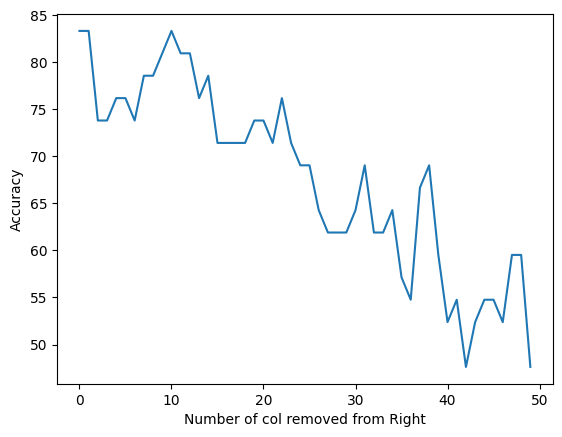

In [17]:
# Delete col from right
ind = []
accur = []
best_cols = []
best_acc = 0
best_inx = 0
for i in range(len(disc_df.columns), 0, -1):
    new_X = disc_df.iloc[:, :i]
    X_train, X_test, y_train, y_test = train_test_split(
        new_X, y, test_size=0.2, random_state=42
    )
    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    # print(f"Columns till {i}: Acc = {acc:.2f}%")
    if acc > best_acc:
        best_acc = acc
        best_inx = i
        best_cols = new_X.columns

    ind.append(len(disc_df.columns) - i)
    accur.append(acc)

print(f"Columns till {best_inx}, cols = {best_cols}: Acc = {best_acc:.2f}%")
plt.plot(ind, accur)
plt.xlabel("Number of col removed from Right")
plt.ylabel("Accuracy")
plt.show()

Columns from 17, cols = Index(['C49', 'C26', 'C28', 'C7', 'C6', 'C44', 'C29', 'C13', 'C25', 'C23',
       'C46', 'C21', 'C8', 'C24', 'C14', 'C17', 'C30', 'C47', 'C11', 'C15',
       'C16', 'C20', 'C22', 'C18', 'C39', 'C41', 'C48', 'C9', 'C32', 'C33',
       'C35', 'C36', 'C43'],
      dtype='str'): Acc = 90.48%


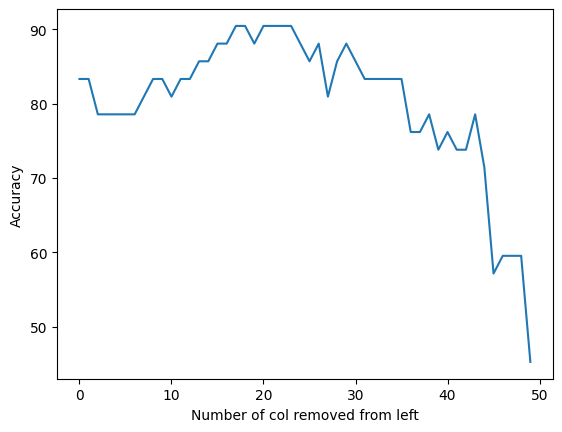

In [14]:
# Delete col from left
ind = []
accur = []
best_acc = 0
best_inx = 0
best_cols = []
for i in range(0, len(disc_df.columns)):
    new_X = disc_df.iloc[:, i:]
    X_train, X_test, y_train, y_test = train_test_split(
        new_X, y, test_size=0.2, random_state=42
    )
    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    # print(f"Columns from {i}: Acc = {acc:.2f}%")
    ind.append(i)
    accur.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_inx = i
        best_cols = new_X.columns

print(f"Columns from {best_inx}, cols = {best_cols}: Acc = {best_acc:.2f}%")
plt.plot(ind, accur)
plt.xlabel("Number of col removed from left")
plt.ylabel("Accuracy")
plt.show()

In [15]:
# from itertools import combinations


# def get_subs(a):
#     for r in range(1, len(a) + 1):
#         for g in combinations(a, r):
#             for sublist in g:
#                 yield list(g)


def get_subs(a):
    for i in range(len(a)):
        for j in range(i + 1, len(a) + 1):
            yield a[i:j]

In [16]:
cols = disc_df.columns
best_acc = 0
best_cols = []
for col in get_subs(cols):
    new_X = disc_df[col]
    X_train, X_test, y_train, y_test = train_test_split(
        new_X, y, test_size=0.2, random_state=42
    )
    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    # print(f"Columns from {i}: Acc = {acc:.2f}%")
    if acc > best_acc:
        best_acc = acc
        best_cols = col


print(f"Columns from {best_cols}: Acc = {best_acc:.2f}%")

Columns from Index(['C7', 'C6', 'C44', 'C29', 'C13', 'C25', 'C23', 'C46', 'C21', 'C8',
       'C24', 'C14', 'C17', 'C30', 'C47', 'C11', 'C15', 'C16', 'C20', 'C22',
       'C18', 'C39', 'C41', 'C48', 'C9', 'C32', 'C33', 'C35', 'C36'],
      dtype='str'): Acc = 95.24%
